## Imports

In [65]:
from collections import defaultdict
import re
import string

from wordcloud import STOPWORDS
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# EDA

#### Memory usage

In [33]:
df_train = pd.read_csv("data/train.csv", dtype={"id": np.int16, "target": np.int8})
df_test = pd.read_csv("data/test.csv", dtype={"id": np.int8})

print(f"Train shape {df_train.shape}")
print(f"Train mem usage {df_train.memory_usage().sum() / 1024**2:.3f} MB")
print(f"Test shape {df_test.shape}")
print(f"Test mem usage {df_test.memory_usage().sum() / 1024**2:.3f} MB")

Train shape (7613, 5)
Train mem usage 0.196 MB
Test shape (3263, 4)
Test mem usage 0.078 MB


## 1. Keyword and location

#### 1.1 Missing values

In [34]:
df_train.isna().mean()

id          0.000000
keyword     0.008013
location    0.332720
text        0.000000
target      0.000000
dtype: float64

In [35]:
df_test.isna().mean()

id          0.000000
keyword     0.007968
location    0.338645
text        0.000000
dtype: float64

Missing value ratios are almost identical, so train and test datasets are likely taken from the same sample

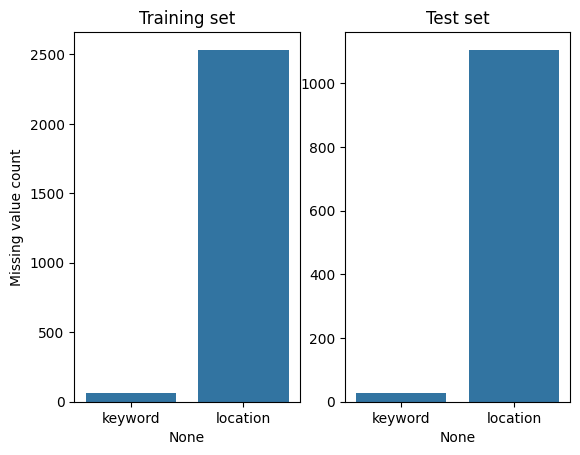

In [36]:
missing_cols = ["keyword", "location"]

fig, subplots = plt.subplots(ncols=2)
sns.barplot(
    x=df_train[missing_cols].isna().sum().index,
    y=df_train[missing_cols].isna().sum().values,
    ax=subplots[0],
)
sns.barplot(
    x=df_test[missing_cols].isna().sum().index,
    y=df_test[missing_cols].isna().sum().values,
    ax=subplots[1],
)

subplots[0].set_ylabel("Missing value count")
subplots[0].tick_params(axis="x")
subplots[0].tick_params(axis="y")
subplots[1].tick_params(axis="x")
subplots[1].tick_params(axis="y")

subplots[0].set_title("Training set")
subplots[1].set_title("Test set")

plt.show()

In [37]:
for df in (df_train, df_test):
    for col in missing_cols:
        df[col] = df[col].fillna(f"no_{col}")

### 1.2 Cardinality and target distribution

In [38]:
print(
    f"Unique values in keyword {df_train['keyword'].nunique()} in train, {df_test['keyword'].nunique()} in test"
)
print(
    f"Unique values in location {df_train['location'].nunique()} in train, {df_test['location'].nunique()} in test"
)

Unique values in keyword 222 in train, 222 in test
Unique values in location 3342 in train, 1603 in test


Some cleaning because without it plots crash

In [42]:
cols_to_clean = ["keyword", "location"]

for df in (df_train, df_test):
    for col in cols_to_clean:
        df[col] = (
            df[col]
            .astype(str)
            .str.replace(r"[^a-zA-Z0-9_ ]", "", regex=True)
            .replace("", f"no_{col}")
        )

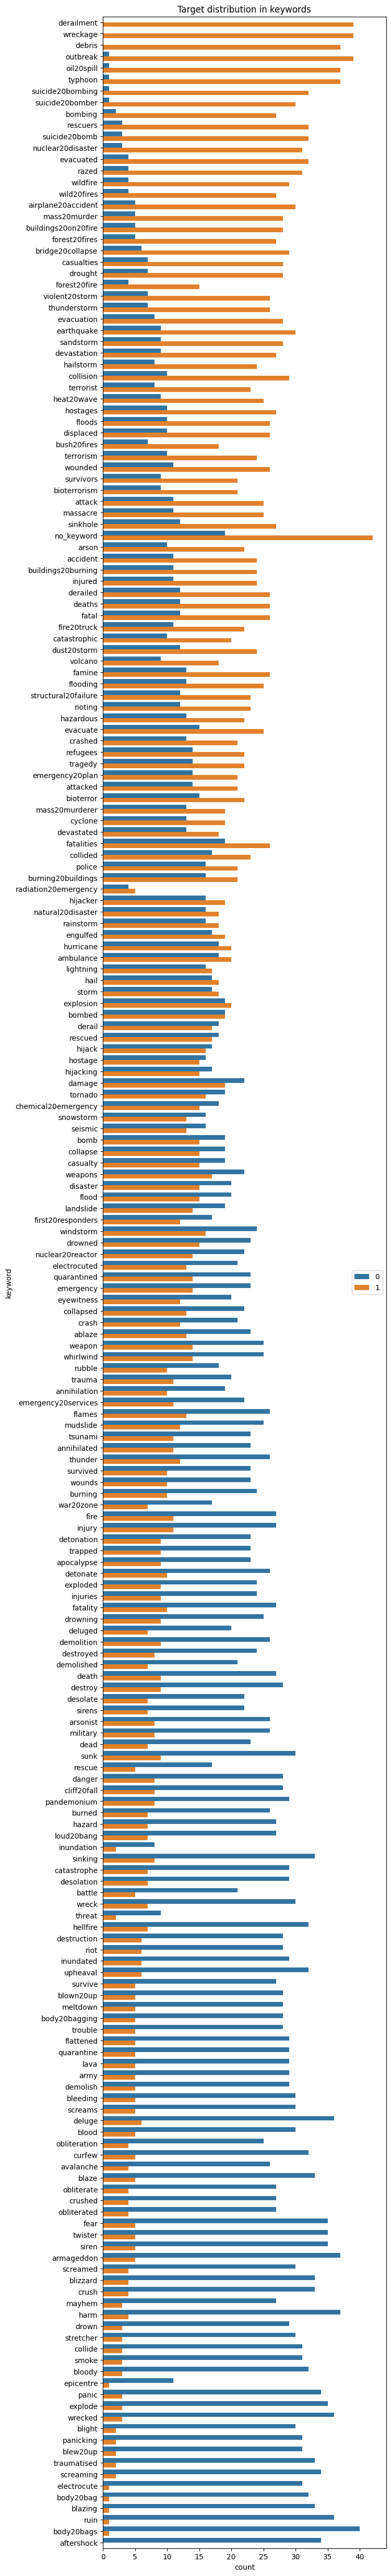

In [46]:
df_train["target_mean"] = df_train.groupby("keyword")["target"].transform("mean")

fig = plt.figure(figsize=(7, 63))

sns.countplot(
    y=df_train.sort_values(by="target_mean", ascending=False)["keyword"],
    hue=df_train.sort_values(by="target_mean", ascending=False)["target"],
)

plt.tick_params(axis="x")
plt.tick_params(axis="y")
plt.legend()
plt.title("Target distribution in keywords")

plt.show()

df_train.drop(columns=["target_mean"], inplace=True)

## 2. Meta features

Extended features

In [50]:
df_train["word_count"] = df_train["text"].apply(lambda x: len(str(x).split()))
df_test["word_count"] = df_test["text"].apply(lambda x: len(str(x).split()))

df_train["unique_word_count"] = df_train["text"].apply(lambda x: len(set(str(x).split())))
df_test["unique_word_count"] = df_test["text"].apply(lambda x: len(set(str(x).split())))

# word like "the", "a" etc.
df_train["stop_word_count"] = df_train["text"].apply(
    lambda x: len([w for w in str(x).lower().split() if w in STOPWORDS])
)
df_test["stop_word_count"] = df_test["text"].apply(
    lambda x: len([w for w in str(x).lower().split() if w in STOPWORDS])
)

df_train["char_count"] = df_train["text"].apply(lambda x: len(str(x)))
df_test["char_count"] = df_test["text"].apply(lambda x: len(str(x)))

df_train["punctuation_count"] = df_train["text"].apply(
    lambda x: len([c for c in str(x) if c in string.punctuation])
)
df_test["punctuation_count"] = df_test["text"].apply(
    lambda x: len([c for c in str(x) if c in string.punctuation])
)

df_train["hashtag_count"] = df_train["text"].apply(lambda x: len([c for c in str(x) if c == "#"]))
df_test["hashtag_count"] = df_test["text"].apply(lambda x: len([c for c in str(x) if c == "#"]))

df_train["mention_count"] = df_train["text"].apply(lambda x: len([c for c in str(x) if c == "@"]))
df_test["mention_count"] = df_test["text"].apply(lambda x: len([c for c in str(x) if c == "@"]))

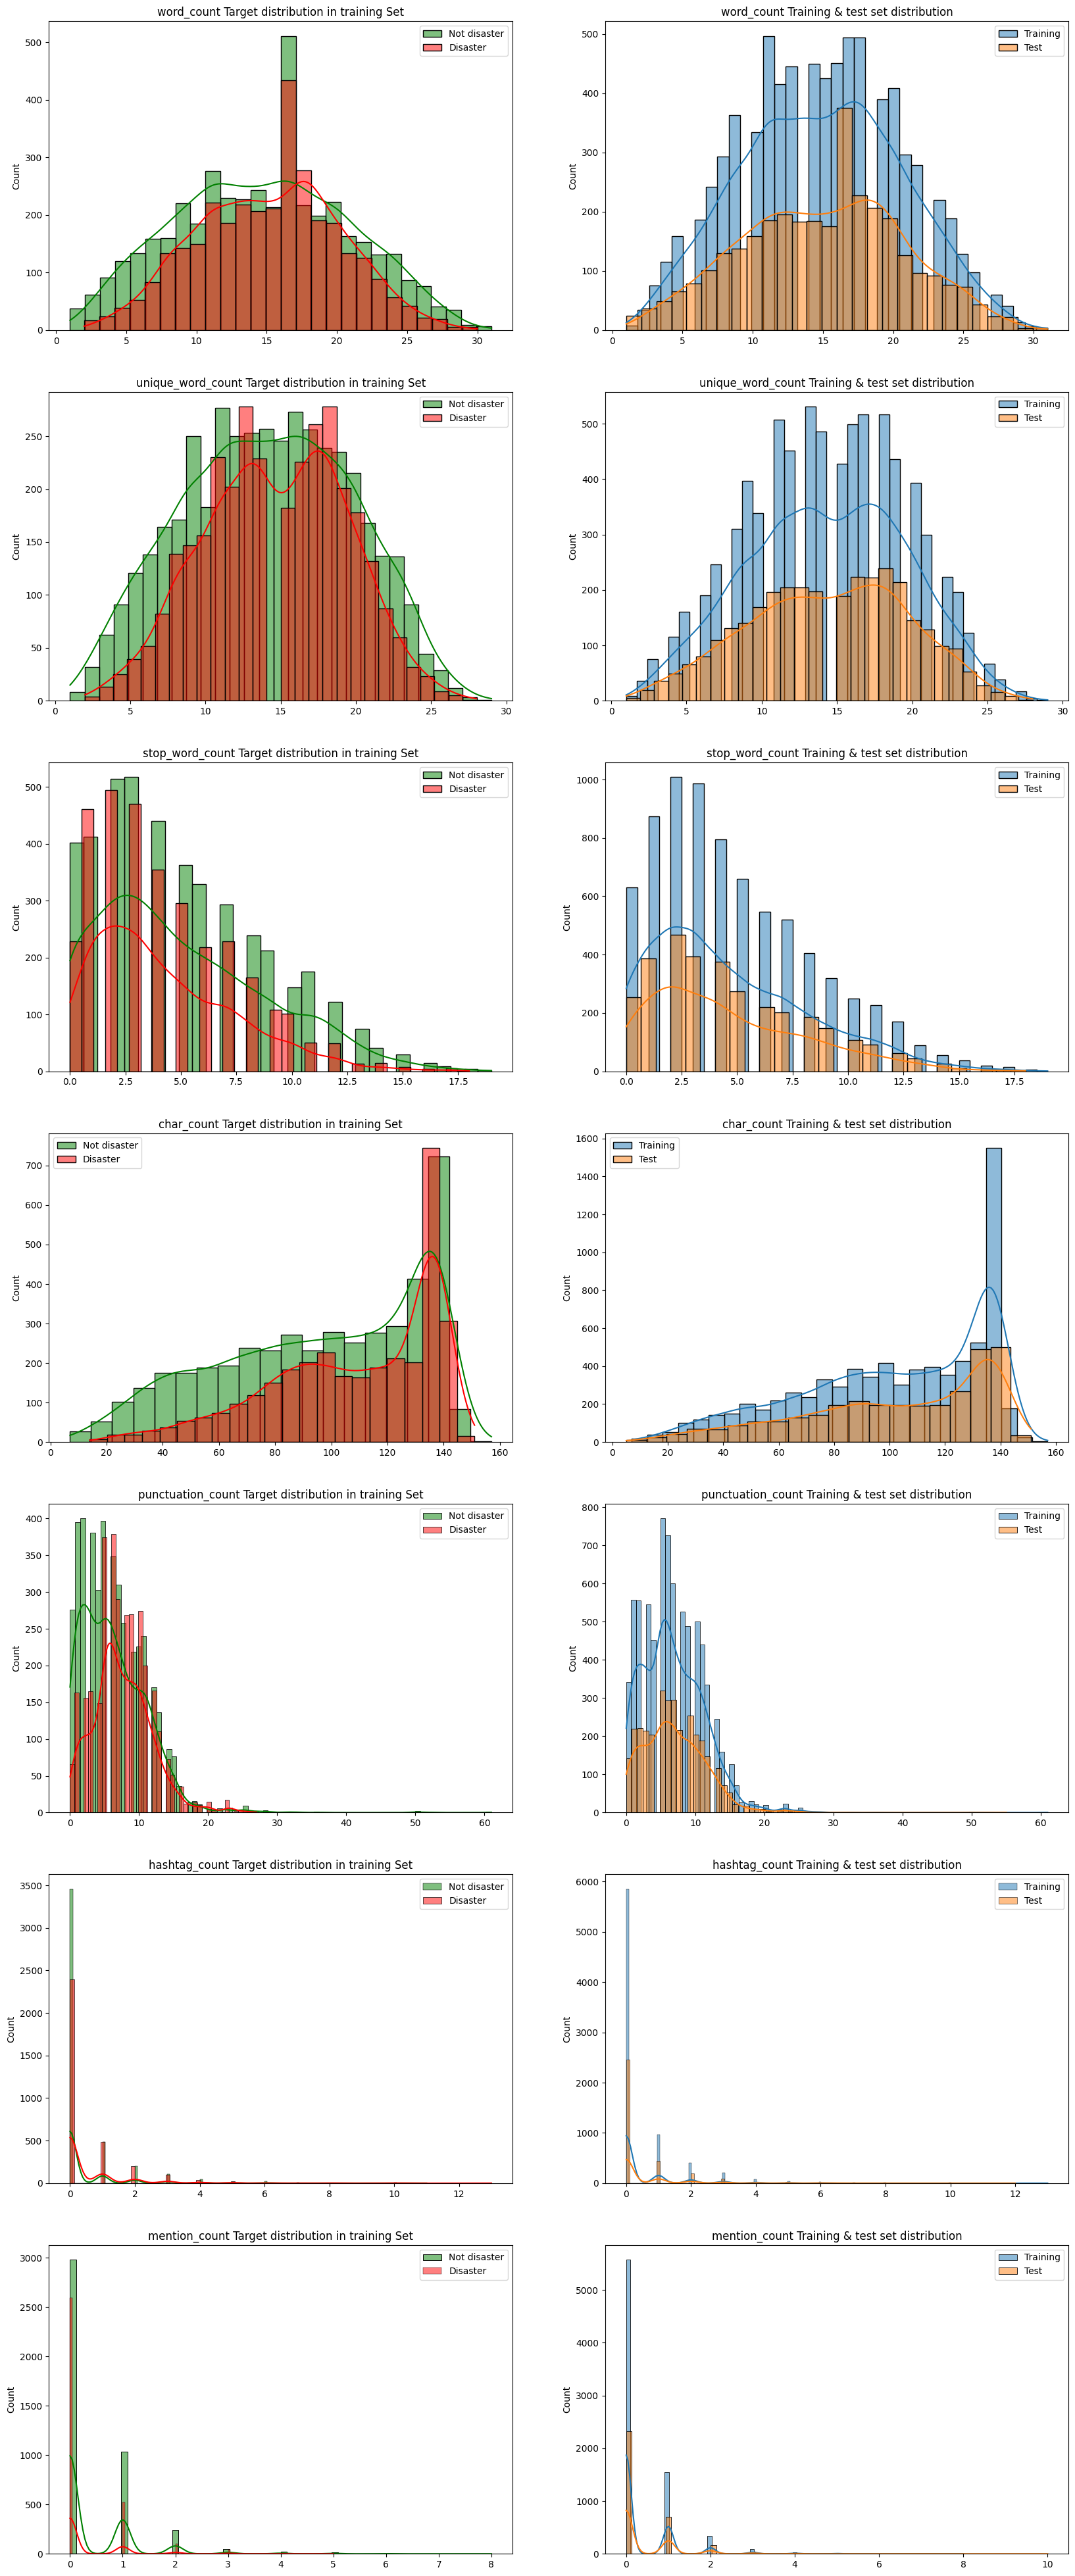

In [53]:
METAFEATURES = [
    "word_count",
    "unique_word_count",
    "stop_word_count",
    "char_count",
    "punctuation_count",
    "hashtag_count",
    "mention_count",
]
DISASTER_TWEETS = df_train["target"] == 1

fig, subplots = plt.subplots(ncols=2, nrows=len(METAFEATURES), figsize=(20, 50))

for i, feature in enumerate(METAFEATURES):
    # Target split
    sns.histplot(
        x=df_train.loc[~DISASTER_TWEETS][feature],
        label="Not disaster",
        ax=subplots[i][0],
        color="green",
        kde=True,
    )

    sns.histplot(
        x=df_train.loc[DISASTER_TWEETS][feature],
        label="Disaster",
        ax=subplots[i][0],
        color="red",
        kde=True,
    )

    # Train vs Test
    sns.histplot(
        x=df_train[feature],
        label="Training",
        ax=subplots[i][1],
        kde=True,
    )

    sns.histplot(
        x=df_test[feature],
        label="Test",
        ax=subplots[i][1],
        kde=True,
    )

    for j in range(2):
        subplots[i][j].set_xlabel("")
        subplots[i][j].tick_params(axis="x")
        subplots[i][j].tick_params(axis="y")
        subplots[i][j].legend()

    subplots[i][0].set_title(f"{feature} Target distribution in training Set")
    subplots[i][1].set_title(f"{feature} Training & test set distribution")

plt.show()

Metafeatures have different distributions for disaster and non-disaster tweets, so they can be useful in models

## 3. Target and N-grams

### 3.1. Target

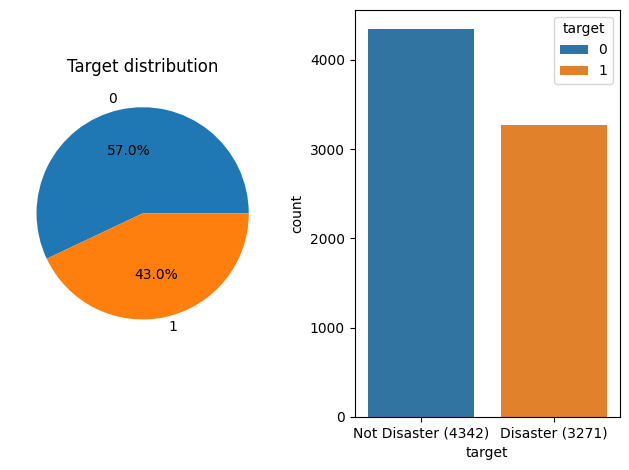

In [63]:
disaster_count = df_train.target.sum()
non_disaster_count = df_train.shape[0] - disaster_count

disaster_percent = 100 * df_train.target.mean()
non_disaster_percent = 100 - disaster_percent

fig, subplots = plt.subplots(ncols=2)

# Pie
df_train["target"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    ax=subplots[0],
)
subplots[0].set_title("Target distribution")

# Countplot
sns.countplot(
    data=df_train,
    x="target",
    hue="target",
    ax=subplots[1],
)

subplots[1].set_xticks([0, 1])
subplots[1].set_xticklabels(
    [
        f"Not Disaster ({non_disaster_count})",
        f"Disaster ({disaster_count})",
    ]
)

plt.tight_layout()
plt.show()

Classes are balanced, so stratification by target in cross-validation isn't mandatory

In [69]:
def tokenize(text: str) -> list[str]:
    """Split text into words"""
    return re.findall(r"\b\w+\b", text.lower())


def generate_ngrams(text: str, n_gram=1) -> list[str]:
    """N-grams generation"""
    tokens = [t for t in tokenize(text) if t not in STOPWORDS]
    ngrams = zip(*[tokens[i:] for i in range(n_gram)])
    return [" ".join(ngram) for ngram in ngrams]


N = 50

# Unigrams
disaster_unigrams = defaultdict(int)
nondisaster_unigrams = defaultdict(int)

for tweet in df_train[DISASTER_TWEETS]["text"]:
    for word in generate_ngrams(tweet):
        disaster_unigrams[word] += 1

for tweet in df_train[~DISASTER_TWEETS]["text"]:
    for word in generate_ngrams(tweet):
        nondisaster_unigrams[word] += 1

df_disaster_unigrams = pd.DataFrame(sorted(disaster_unigrams.items(), key=lambda x: x[1])[::-1])
df_nondisaster_unigrams = pd.DataFrame(
    sorted(nondisaster_unigrams.items(), key=lambda x: x[1])[::-1]
)

# Bigrams
disaster_bigrams = defaultdict(int)
nondisaster_bigrams = defaultdict(int)

for tweet in df_train[DISASTER_TWEETS]["text"]:
    for word in generate_ngrams(tweet, n_gram=2):
        disaster_bigrams[word] += 1

for tweet in df_train[~DISASTER_TWEETS]["text"]:
    for word in generate_ngrams(tweet, n_gram=2):
        nondisaster_bigrams[word] += 1

df_disaster_bigrams = pd.DataFrame(sorted(disaster_bigrams.items(), key=lambda x: x[1])[::-1])
df_nondisaster_bigrams = pd.DataFrame(sorted(nondisaster_bigrams.items(), key=lambda x: x[1])[::-1])

# Trigrams
disaster_trigrams = defaultdict(int)
nondisaster_trigrams = defaultdict(int)

for tweet in df_train[DISASTER_TWEETS]["text"]:
    for word in generate_ngrams(tweet, n_gram=3):
        disaster_trigrams[word] += 1

for tweet in df_train[~DISASTER_TWEETS]["text"]:
    for word in generate_ngrams(tweet, n_gram=3):
        nondisaster_trigrams[word] += 1

df_disaster_trigrams = pd.DataFrame(sorted(disaster_trigrams.items(), key=lambda x: x[1])[::-1])
df_nondisaster_trigrams = pd.DataFrame(
    sorted(nondisaster_trigrams.items(), key=lambda x: x[1])[::-1]
)

### 3.2 Unigrams

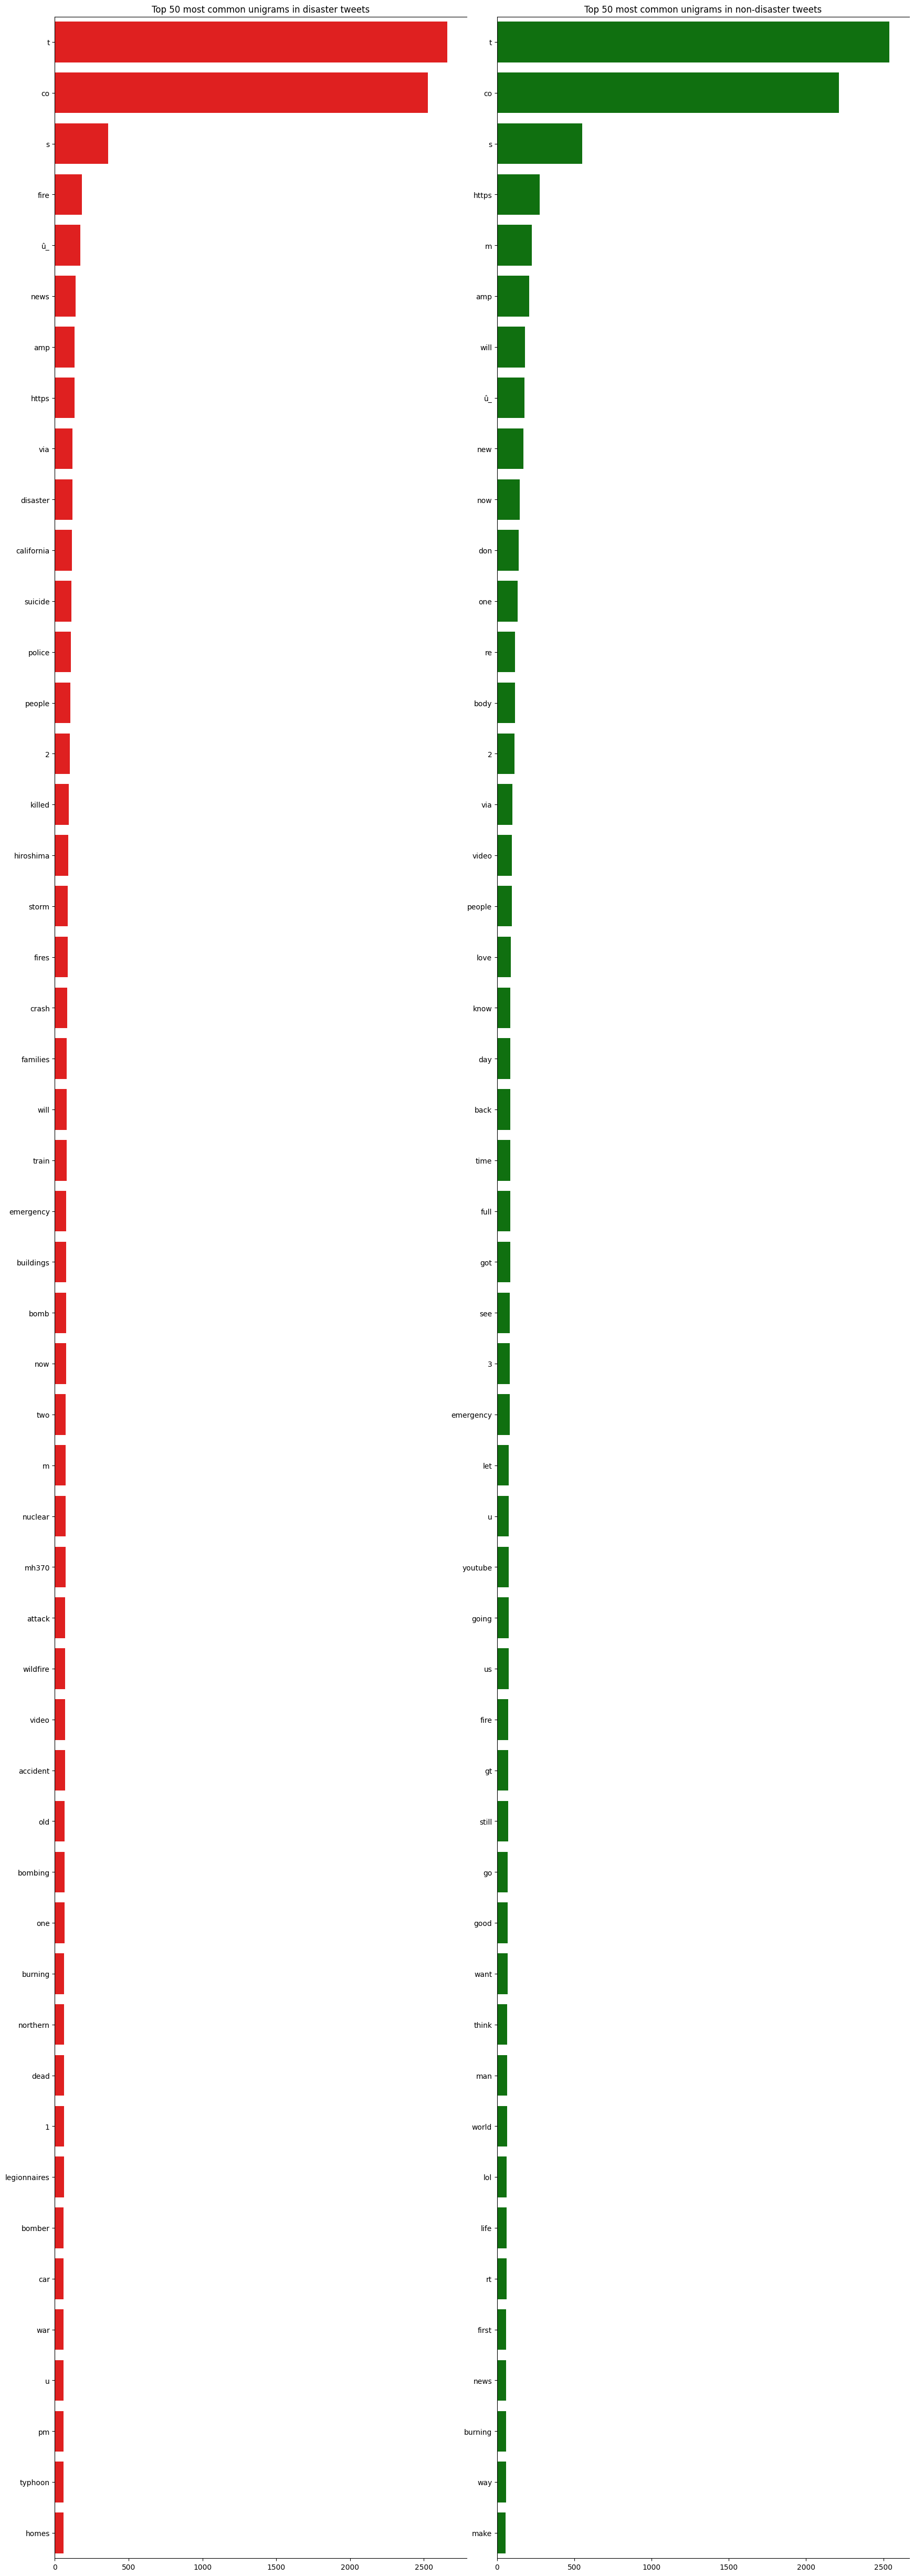

In [70]:
fig, subplots = plt.subplots(ncols=2, figsize=(17, 49))
plt.tight_layout()

sns.barplot(
    y=df_disaster_unigrams[0].values[:N],
    x=df_disaster_unigrams[1].values[:N],
    ax=subplots[0],
    color="red",
)
sns.barplot(
    y=df_nondisaster_unigrams[0].values[:N],
    x=df_nondisaster_unigrams[1].values[:N],
    ax=subplots[1],
    color="green",
)

for i in range(2):
    subplots[i].spines["right"].set_visible(False)
    subplots[i].set_xlabel("")
    subplots[i].set_ylabel("")
    subplots[i].tick_params(axis="x")
    subplots[i].tick_params(axis="y")

subplots[0].set_title(f"Top {N} most common unigrams in disaster tweets")
subplots[1].set_title(f"Top {N} most common unigrams in non-disaster tweets")

plt.show()

### 3.3 Bigrams

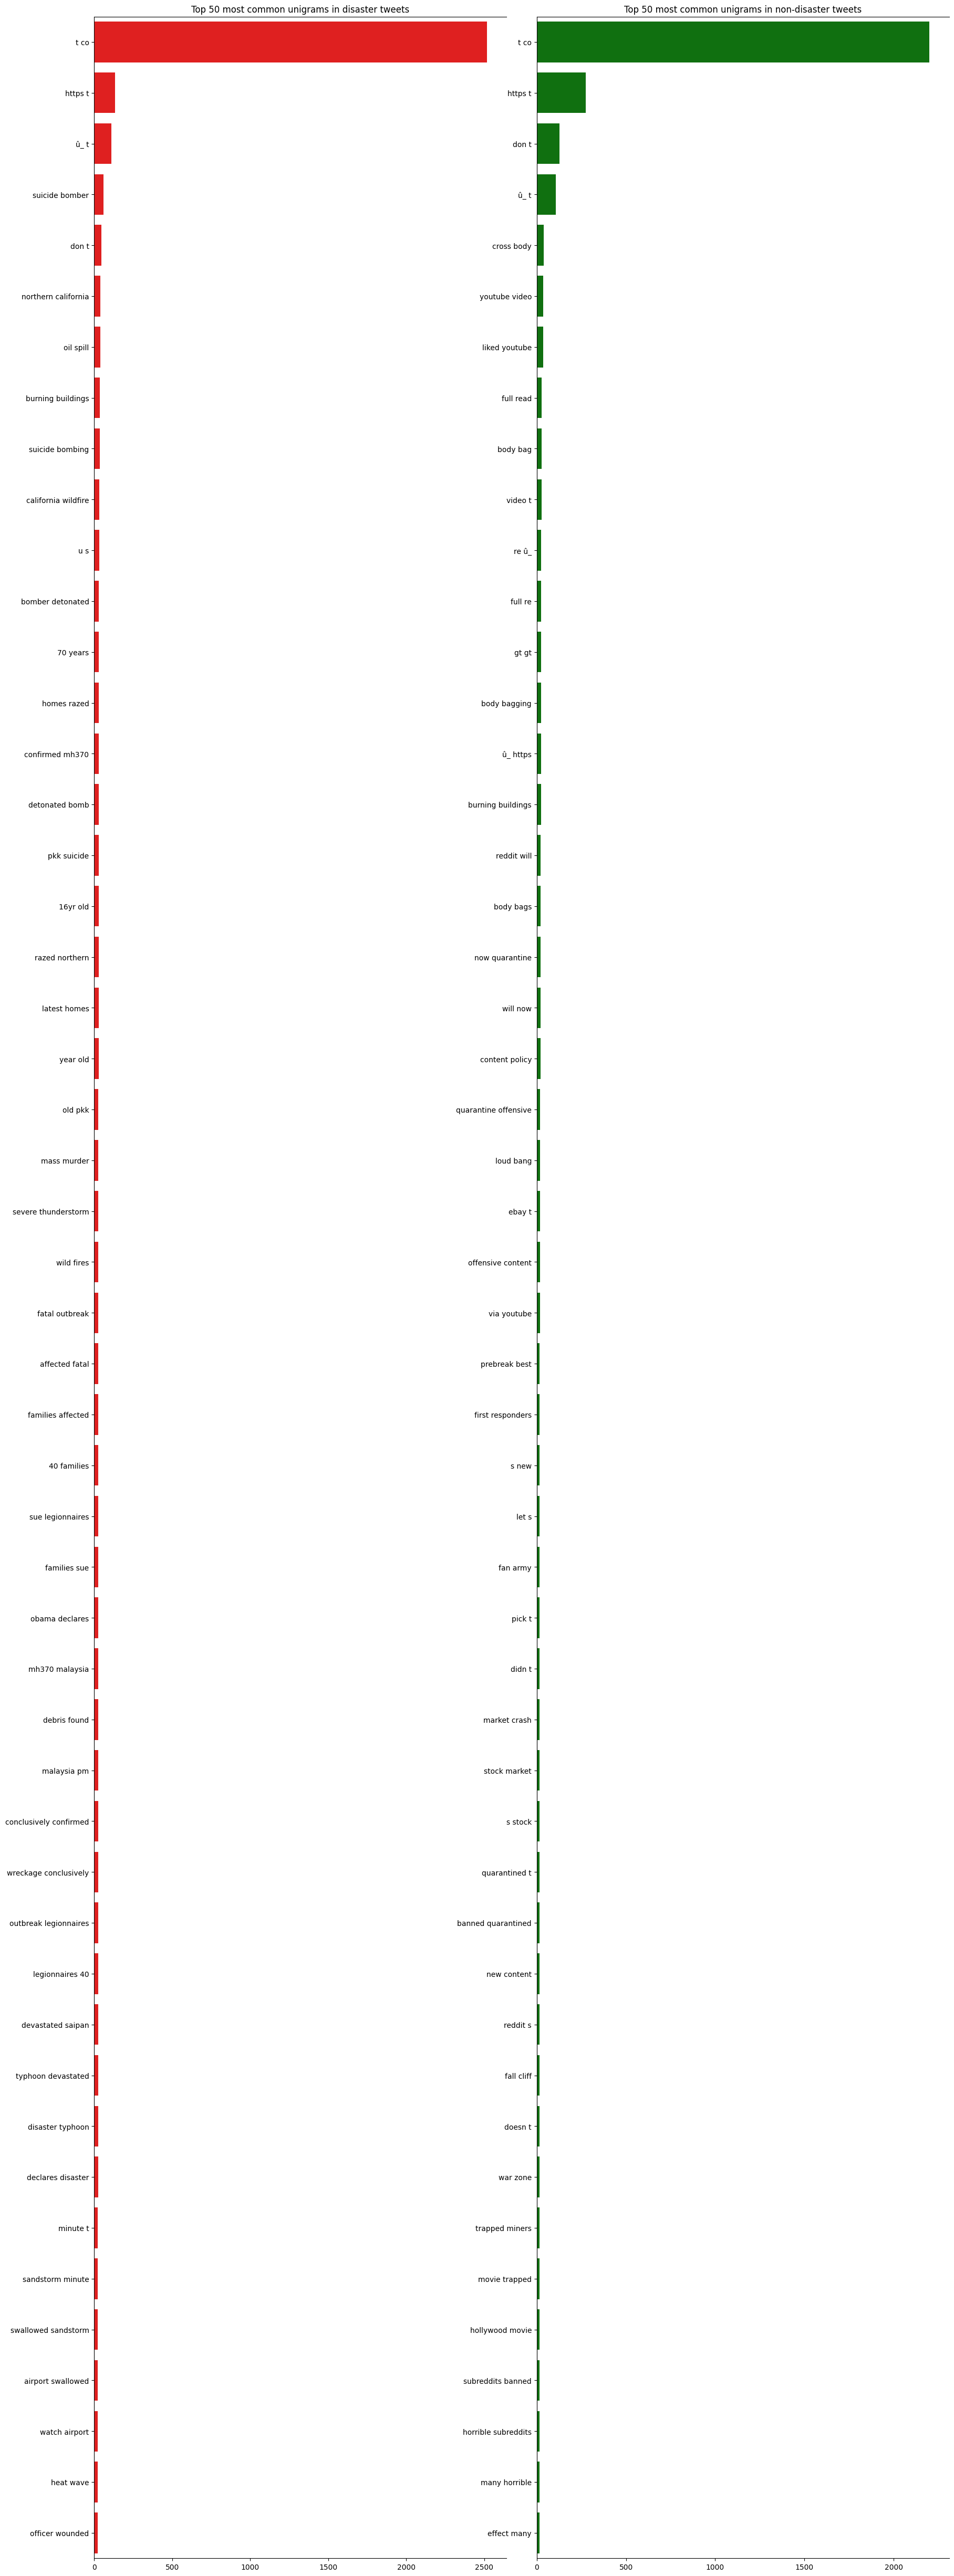

In [71]:
fig, subplots = plt.subplots(ncols=2, figsize=(17, 49))
plt.tight_layout()

sns.barplot(
    y=df_disaster_bigrams[0].values[:N],
    x=df_disaster_bigrams[1].values[:N],
    ax=subplots[0],
    color="red",
)
sns.barplot(
    y=df_nondisaster_bigrams[0].values[:N],
    x=df_nondisaster_bigrams[1].values[:N],
    ax=subplots[1],
    color="green",
)

for i in range(2):
    subplots[i].spines["right"].set_visible(False)
    subplots[i].set_xlabel("")
    subplots[i].set_ylabel("")
    subplots[i].tick_params(axis="x")
    subplots[i].tick_params(axis="y")

subplots[0].set_title(f"Top {N} most common unigrams in disaster tweets")
subplots[1].set_title(f"Top {N} most common unigrams in non-disaster tweets")

plt.show()

Some bigrams are common, but there are some differencies at the top

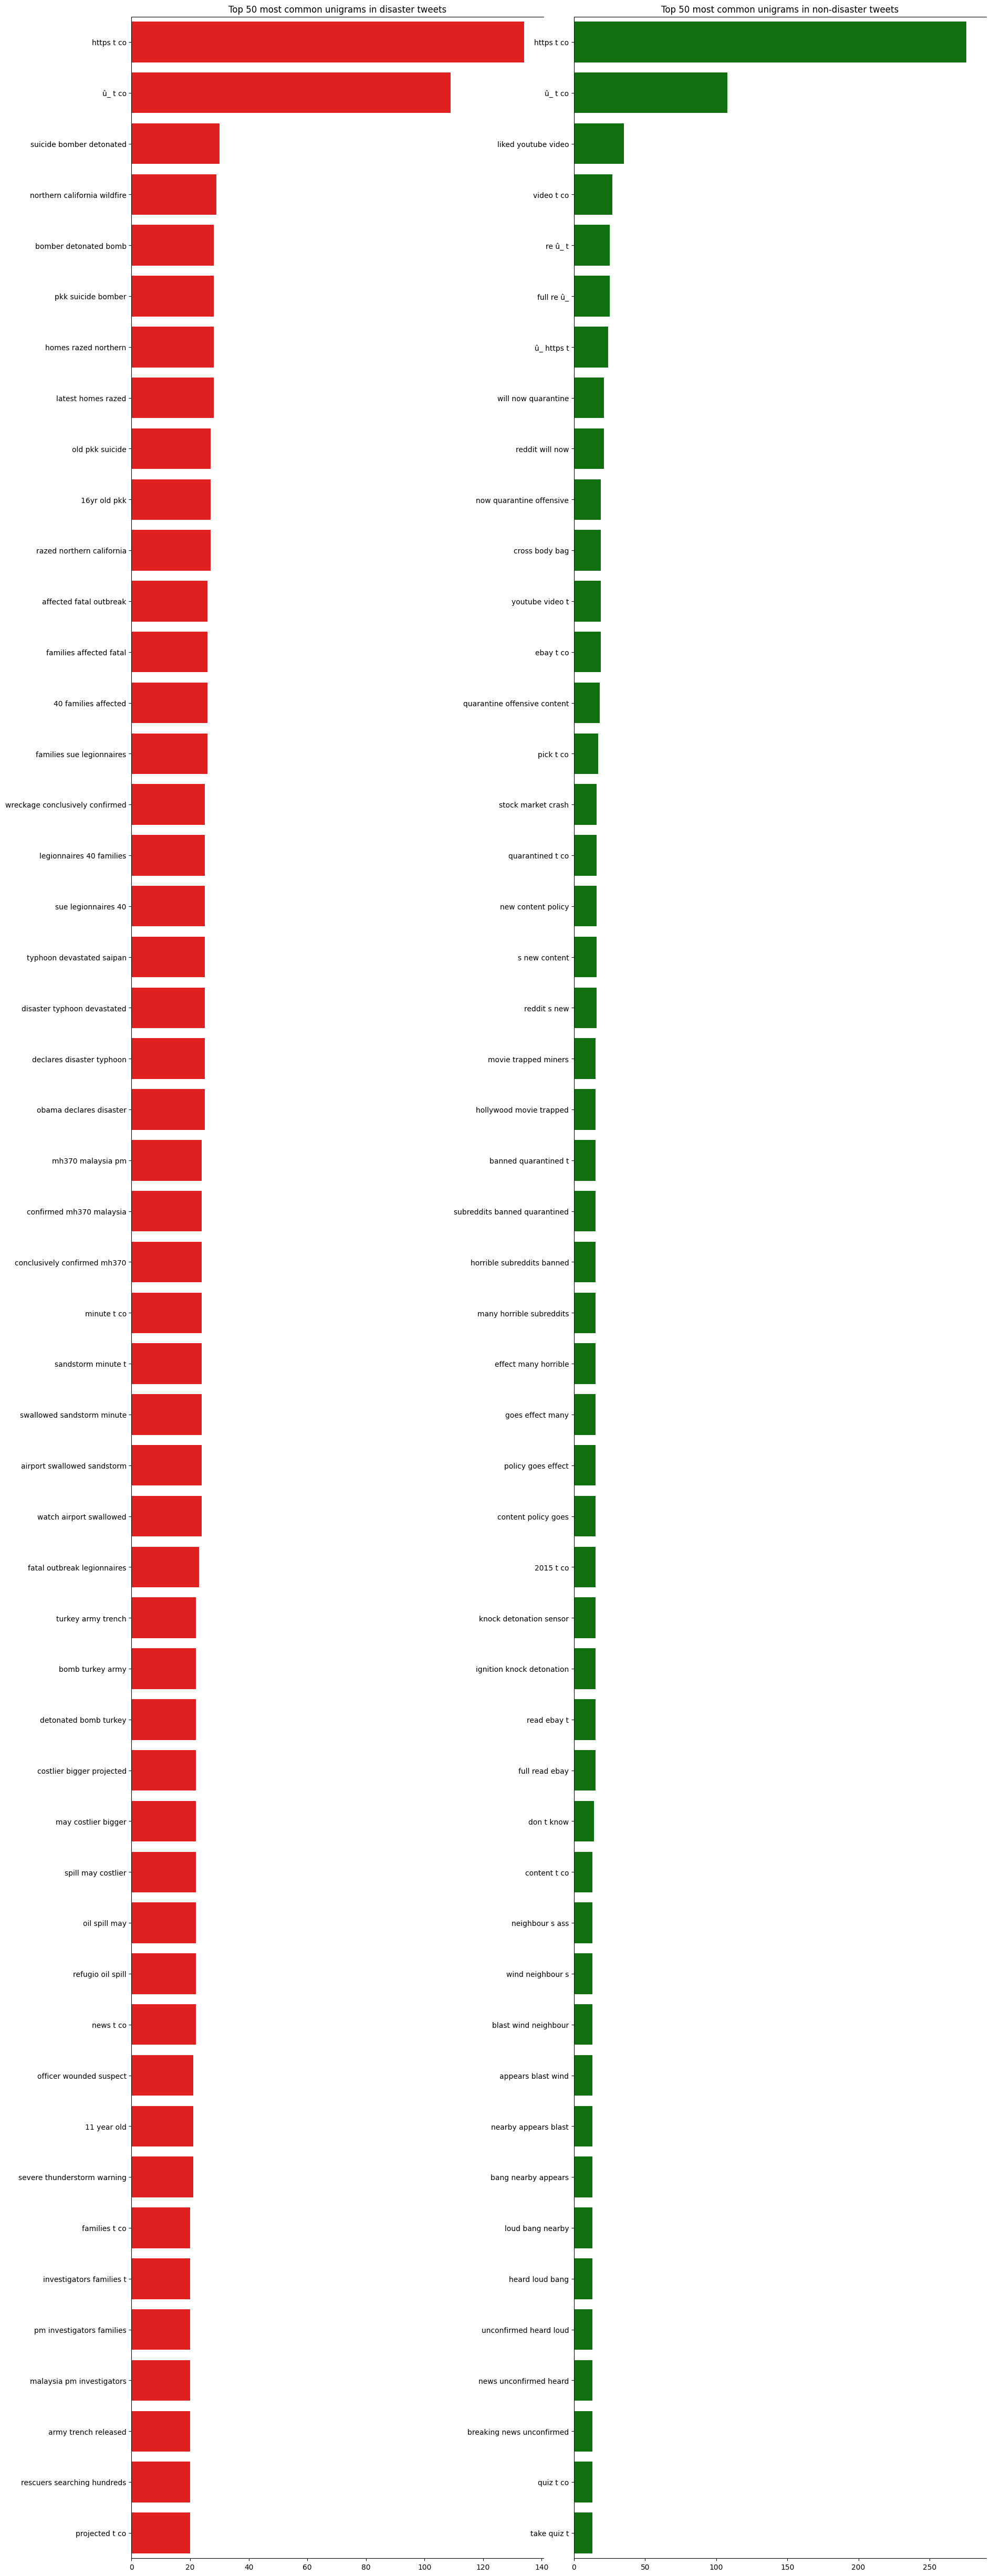

In [72]:
fig, subplots = plt.subplots(ncols=2, figsize=(17, 49))
plt.tight_layout()

sns.barplot(
    y=df_disaster_trigrams[0].values[:N],
    x=df_disaster_trigrams[1].values[:N],
    ax=subplots[0],
    color="red",
)
sns.barplot(
    y=df_nondisaster_trigrams[0].values[:N],
    x=df_nondisaster_trigrams[1].values[:N],
    ax=subplots[1],
    color="green",
)

for i in range(2):
    subplots[i].spines["right"].set_visible(False)
    subplots[i].set_xlabel("")
    subplots[i].set_ylabel("")
    subplots[i].tick_params(axis="x")
    subplots[i].tick_params(axis="y")

subplots[0].set_title(f"Top {N} most common unigrams in disaster tweets")
subplots[1].set_title(f"Top {N} most common unigrams in non-disaster tweets")

plt.show()

Trigrams are self-explanatory